#### run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [65]:
# !pip install xgboost
# !pip install imbalanced-learn
# !pip install catboost
# !pip install optuna
# !pip install torch
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
import random
import torch
import optuna
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
random.seed(35)
np.random.seed(35)

client = bigquery.Client()

def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [66]:
# Get features
sql = """
SELECT
    f.* EXCEPT (asdb_plan_key, post_mnths, first_prv_dt, last_prv_dt, index_dt)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` AS f
WHERE 1=1
    AND NOT asdb_plan_key IN (33, 54)
    AND post_mnths >= 6
"""
df_og = client.query(sql).to_dataframe() 

df_og.shape
#2,191,619 members who qualify per BQ
#1,875,523 have embeddings
#1,647,108 after we cut out too short of followup time

(1636185, 305)

In [67]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    asdb_member_key
    , acute_ip_flag
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_outcome_ip` AS o
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_og = client.query(sql).to_dataframe() 
outcome_og.shape

(1636179, 2)

### Data Preprocessing

#### Fill in zeros

In [68]:
from pandas.api.types import is_integer_dtype as is_integer
from pandas.api.types import is_float_dtype as is_float
import re

emb_pattern = r'emb[0-255]+'
emb_col = [col for col in df_og.columns if re.match(emb_pattern ,col)]
df_og[emb_col] = df_og[emb_col].fillna(0)
for c in df_og.columns: 
    dt = df_og[c].dtype
    if is_integer(dt) or is_float(dt):
        df_og[c]=df_og[c].fillna(0) 
        # print("Floatint:", dt)
    else:
        try:
            df_og[c]= df_og[c].fillna('')
        except:
            print("ERROR - DATE VARIABLE FOUND", dt)

#### One Hot Encode Categorical

In [69]:
#  0 := categorical, 1 := continuous, 2 := binary
nem_to_type = {
    'narc':2, 
    # 'otc_fills_yr2': 1,
    # 'otc_fills_yr1':1,  
    'COP':2, 
    'sleep_apnea':2, 
    'spinal_inj':2,
    'back':2,
    'substance':2,
    'ALC':2,
    'bipolar':2,
    'psychoses':2,
    'EDO':2, 
    'SCA':2, 
    'DIA':2, 
    'DEP':2, 
    'abdominal_pain':2, 
    'OST':2, 
    'AID':2, 
    'IDA':2, 
    'ANX':2, 
    'DEM':2, 
    'CYS':2, 
    'autoimmune':2, 
    'MOH':2, 
    'HEM':2, 
    'esrd':2, 
    'HepC':2, 
    'HYP':2, 
    'HYC':2, 
    'immune':2, 
    'intel_dsblty':2, 
    'meta_cancer':2, 
    'liver_dis':2, 
    'MSS':2, 
    'OBE':2, 
    'oud':2, 
    'liver_other':2, 
    'paralysis':2, 
    'PAR':2, 
    'PUD':0, 
    'hmd':2, 
    'PVD':2, 
    'CRO':2, 
    'AST':2, 
    'EPL':2, 
    'low_med_sev_ed_flag_yr2':2, 
    'med_high_sev_ed_flag_yr2':2, 
    'high_sev_ed_flag_yr2':2, 
    'acute_ip_flag_yr1':2, 
    'CHO':2,
    'burns':2, 
    'acute_ip_flag_yr2':2, 
    'cad':2, 
    'Cancer':2, 
    'ed_flag_yr2':2, 
    'high_sev_ed_flag_yr1':2, 
    'med_sev_ed_flag_yr2':2, 
    'AUT':2, 
    'med_high_sev_ed_flag_yr1':2, 
    'low_med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr1':2, 
    'CBD':2, 
    'CHF':2, 
    'CRF':2, 
    'VNA':2, 
    'CHD':2, 
    'ed_flag_yr1':2, 
    'med_sev_ed_flag_yr1':2, 
    'low_sev_ed_flag_yr2':2, 
    'urbsubr':0, 
    'gender':0, # TODO: IF = M, 1 ELIF = F 0 ELSE NULL 
    'cms_prost_cancer_scrn':0, 
    'cms_hpv_scrn':0, 
    'cms_cvd_scrn':0, 
    'cms_lung_cancer_scrn':0, 
    'cms_pelvic':0,
    'coa_population_group':0, 
    'cms_pap':0, 
    'cms_t2d_scrn':0, 
    'cms_bone_scrn':0, 
    'cms_alc_scrn':0,
    'cms_ibt_cvd':0, 
    'cms_col_scrn':0,
    'index_dt':0, 
    'cms_ibt_obese':0, 
    'cms_flu_vax':0, 
    'cms_pneum_vax':0, 
    'cms_dep_scrn':0,
    'tenure_yr2':1, # either 
    'tenure_yr1':1, # either
    'cms_hepb_vax':0,
    'low_sev_ed_visits_yr2':0, # 7/2/24 removed
    'coa_population_category':0, 
    'cms_mam_scrn':0, # 7/2/24 removed
    'low_sev_ed_visits_yr1':1,
    'sum_acute_ip_admits_yr2':1,
    'sum_acute_ip_admits_yr1':1,
    'cms_tobacco':0,# 7/2/24 removed
    'low_med_sev_ed_visits_yr2':1, 
    'cms_t2d_train':0, # 7/2/24 removed
    'sum_preventable_yr2':1, 
    'cms_hepb_scrn':0, ###
    'sum_preventable_yr1':1, 
    'major_chronic_cnt':1, 
    'low_med_sev_ed_visits_yr1':1,
    'sum_ob':1, 
    'sum_unnecessary_yr2':1, 
    'sum_chol_lab':1, 
    'cms_nutrition':0,  # 7/2/24 removed
    'coe_anesth_clm_yr2':1, 
    'sum_a1c_lab':1, 
    'sum_unnecessary_yr1':1, 
    'sum_avoidable_yr2':1, 
    'gpi2_cnt_yr1':1, 
    'high_sev_ed_visits_yr2':1,
    'gpi2_cnt_yr2':1, 
    'ms_brand_fills_yr2':1, 
    'coe_anesth_clm_yr1':1, 
    'med_sev_ed_visits_yr2':1, 
    'cms_sti_scrn':0, 
    'med_high_sev_ed_visits_yr2':1, 
    'high_sev_ed_visits_yr1':1, 
    'ms_brand_fills_yr1':1, 
    'sum_avoidable_yr1':1, 
    'inhaled_steroid_scripts_yr2':1, 
    'med_high_sev_ed_visits_yr1':1, 
    'med_sev_ed_visits_yr1':1, 
    'inhaled_steroid_scripts_yr1':1, 
    'obs_clm_yr2':1,
    'gpi4_cnt_yr2':1,
    'gpi4_cnt_yr1':1,
    'obs_clm_yr1':1, 
    'sum_dme':1, 
    'antianginal_agent_scripts_yr2':1, 
    'mail_order_fills_yr2':1, 
    'branded_generic_fills_yr2':1, 
    'gpi_cnt_yr1':1,
    'gpi_cnt_yr2':1,
    'adi_score':1, 
    'sdi_score':1, 
    'antianginal_agent_scripts_yr1':1, 
    'ethnicity_code':0, 
    'sum_ed_visits_yr2':1,
    'mail_order_fills_yr1':1,
    'uc_clm_yr2':1, 
    'calcium_channel_blk_scripts_yr2':1,
    'antianxiety_scripts_yr2':1, 
    'beta_blocker_scripts_yr2':1, 
    'sum_ed_visits_yr1':1, 
    'branded_generic_fills_yr1':1,
    'coe_maternity_clm_yr2':1,
    'sum_chemo':1, 
    'agenbr':1, 
    'uc_clm_yr1':1,
    'calcium_channel_blk_scripts_yr1':1,
    'coe_maternity_clm_yr1':1,
    'diuretic_scripts_yr2':1,
    'primarylanguage_desc':0, # TODO: Check counts, limit to other if <2000 ppl
    'beta_blocker_scripts_yr1':1, 
    'antianxiety_scripts_yr1':1,
    'antihypertensive_scripts_yr2':1,
    'ndc_cnt_yr1':1, 
    'ndc_cnt_yr2':1, 
    'lipid_lowering_scripts_yr2':1,
    'diuretic_scripts_yr1':1, 
    'coe_surg_clm_yr2':1, 
    'sum_acute_calc_los_yr1':1, 
    'sum_acute_calc_los_yr2':1,
    'sum_pcp':1, 
    'lipid_lowering_scripts_yr1':1, 
    'antihypertensive_scripts_yr1':1,
    'coe_surg_clm_yr1':1,
    'coe_mrx_clm_yr2':1,
    'antidepressant_scripts_yr2':1,
    'coe_mrx_clm_yr1':1, 
    'antipsychotic_scripts_yr2':1, 
    'anticonvulsant_scripts_yr2':1, 
    'antidiabetic_scripts_yr2':1, 
    'antidepressant_scripts_yr1':1, 
    'coe_radio_clm_yr2':1,
    'anticonvulsant_scripts_yr1':1, 
    'coe_radio_clm_yr1':1, 
    'emis_mrx_clm_yr2':1, 
    'coe_ltc_community_clm_yr1':1, 
    'emis_community_clm_yr1':1,
    'coe_ltc_community_clm_yr2':1, 
    'emis_community_clm_yr2':1, 
    'emis_radio_clm_yr1':1, 
    'emis_radio_clm_yr2':1, 
    'antipsychotic_scripts_yr1':1, 
    'antidiabetic_scripts_yr1':1, 
    'emis_mrx_clm_yr1':1,
    'coe_ip_hos_clm_yr2':1,
    'coe_ip_hos_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr2':1,
    'emis_pcp_clm_yr1':1,
    'emis_pcp_clm_yr2':1,
    'coe_phy_clm_yr1':1, 
    'coe_ip_non_hos_clm_yr1':1,
    'inhaled_steroid_days_supply_yr2':1, 
    'coe_phy_clm_yr2':1, 
    'emis_ip_clm_yr2':1,
    'ss_brand_fills_yr2':1, 
    'emis_ip_clm_yr1':1, 
    'inhaled_steroid_days_supply_yr1':1, 
    'coe_eval_clm_yr2':1, 
    'coe_ltc_ins_clm_yr2':1, 
    'emis_ins_clm_yr2':1, 
    'sum_spec':1, 
    'coe_eval_clm_yr1':1, 
    'ss_brand_fills_yr1':1,
    'retail_fills_yr2':1, 
    'retail_fills_yr1':1, 
    'emis_ins_clm_yr1':1, 
    'coe_ltc_ins_clm_yr1':1, 
    'emis_spec_clm_yr2':1,
    'emis_spec_clm_yr1':1,
    'emis_ed_clm_yr2':1,
    'coe_lab_clm_yr2':1, 
    'generic_fills_yr2':1,
    'emis_ed_clm_yr1':1,
    'last_prv_dt':1, 
    'first_prv_dt':1,
    'coe_lab_clm_yr1':1,
    'maint_drug_fills_yr2':1,
    'emis_lab_clm_yr2':1,
    'formulary_fills_yr2':1,
    'emis_lab_clm_yr1':1, 
    'generic_fills_yr1':1, 
    'coe_op_hos_clm_yr2':1, 
    'formulary_fills_yr1':1,
    'emis_misc_clm_yr2':1,
    'maint_drug_fills_yr1':1,
    'coe_op_hos_clm_yr1':1, 
    'rx_claim_cnt_yr2':1, 
    'antianginal_agent_days_supply_yr2':1,
    'coe_mh_clm_yr2':1,
    'coe_mh_clm_yr1':1,
    'emis_misc_clm_yr1':1, 
    'coe_ltc_home_clm_yr2':1,
    'emis_home_clm_yr2':1,
    'antianginal_agent_days_supply_yr1':1, 
    'ltc_clm_yr2':1,
    'coe_ltc_home_clm_yr1':1,
    'emis_home_clm_yr1':1, 
    'emis_hh_clm_yr2':1, 
    'emis_hh_clm_yr1':1, 
    'ltc_clm_yr1':1, 
    'rx_claim_cnt_yr1':1, 
    'calcium_channel_blk_days_supply_yr2':1, 
    'sum_op_visits_yr2':1, 
    'sum_op_visits_yr1':1, 
    'coe_op_non_hos_clm_yr2':1,
    'emis_ambul_clm_yr2':1, 
    'water_quality':1, 
    'coe_op_non_hos_clm_yr1':1, 
    'calcium_channel_blk_days_supply_yr1':1, 
    'beta_blocker_days_supply_yr2':1,
    'emis_ambul_clm_yr1':1,
    'beta_blocker_days_supply_yr1':1, 
    'emis_mh_clm_yr2':1, 
    'emis_mh_clm_yr1':1, 
    'diuretic_days_supply_yr2':1, 
    'antianxiety_days_supply_yr2':1, 
    'lipid_lowering_days_supply_yr2':1, 
    'coe_other_clm_yr2':1, 
    'coe_other_clm_yr1':1,
    'antianxiety_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr2':1,
    'diuretic_days_supply_yr1':1, 
    'lipid_lowering_days_supply_yr1':1, 
    'antihypertensive_days_supply_yr1':1, 
    'antipsychotic_days_supply_yr2':1,
    'antidepressant_days_supply_yr2':1,
    'antipsychotic_days_supply_yr1':1,
    'antidepressant_days_supply_yr1':1, 
    'anticonvulsant_days_supply_yr2':1, 
    'anticonvulsant_days_supply_yr1':1,
    'antidiabetic_days_supply_yr2':1, 
    'antidiabetic_days_supply_yr1':1, 
    'income_inequality':1, 
    'svi_score':1, 
    'days_supply_sum_yr2':1, 
    'zip_weight_avg_medinc':1,
    'days_supply_sum_yr1':1,
    'food_access':1, 
    'citizenship_index':1,
    'acs_social_risk_score':1, 
    'housing_desert':1, 
    'unemployment_index':1,
    'health_habits':1,
    'natural_disaster':1,
    'proactive_health':1,
    'housing_ownership':1, 
    'health_infra':1,
    'language_score':1, 
    'racial_diversity':1, 
    'housing_quality':1,
    'income_index':1,
    'education_index':1,
    'transport_access':1, 
    'disability_score':1,
    'technology_access':1,
    'poverty_score':1, 
    'social_isolation':1,
    'health_access':1,
    'csdi_social_risk_score':1,
     'asdb_member_key':1,
}

In [70]:
index_to_feature = dict(enumerate(df_og.columns))
feature_to_index = {value: key for key, value in index_to_feature.items()}
categorical_features = [feature for feature in nem_to_type if nem_to_type[feature] == 0]
categorical_indices = [feature_to_index[feature] for feature in categorical_features if feature in feature_to_index]
len(categorical_features)

31

In [71]:
# ONE HOT ENCODING
categorical_features.remove('index_dt')
df_og[categorical_features] = df_og[categorical_features].astype(str)
df_og['gender'] = df_og['gender'].map({'M': 1, 'F': 0}).fillna(-1)  
categorical_features.remove('gender')

In [72]:
# ONE HOT ENCODING
from tqdm.notebook import tqdm
from sklearn.preprocessing import OneHotEncoder
min_occurrence = 2000

encoder = OneHotEncoder(sparse_output=False)

for feature in tqdm(categorical_features):
    counts = df_og[feature].value_counts()
    categories_to_keep = counts[counts >= min_occurrence].index
   
    filtered_df = df_og[df_og[feature].isin(categories_to_keep)]
   
    if not filtered_df.empty:
        encoded_data = encoder.fit_transform(filtered_df[[feature]])
        encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([feature]))
       
        df_og = df_og.drop(feature, axis=1)
        df_og = pd.concat([df_og, encoded_df], axis=1)

  0%|          | 0/29 [00:00<?, ?it/s]

In [73]:
df_og.set_index('asdb_member_key', inplace = True)
outcome_og.set_index('asdb_member_key', inplace = True)
merged = df_og.merge(outcome_og, on='asdb_member_key', how='left')

In [74]:
merged.to_feather("OOT.feather")

In [75]:
df_og.shape

(1636185, 384)

In [76]:
merged.shape

(1636185, 385)

In [77]:
list(merged.columns)

['sum_ed_visits_yr1',
 'ed_flag_yr1',
 'sum_avoidable_yr1',
 'sum_unnecessary_yr1',
 'sum_preventable_yr1',
 'low_sev_ed_visits_yr1',
 'low_med_sev_ed_visits_yr1',
 'med_sev_ed_visits_yr1',
 'med_high_sev_ed_visits_yr1',
 'high_sev_ed_visits_yr1',
 'low_sev_ed_flag_yr1',
 'low_med_sev_ed_flag_yr1',
 'med_sev_ed_flag_yr1',
 'med_high_sev_ed_flag_yr1',
 'high_sev_ed_flag_yr1',
 'ed_flag_yr2',
 'sum_ed_visits_yr2',
 'sum_avoidable_yr2',
 'sum_unnecessary_yr2',
 'sum_preventable_yr2',
 'low_med_sev_ed_visits_yr2',
 'med_sev_ed_visits_yr2',
 'med_high_sev_ed_visits_yr2',
 'high_sev_ed_visits_yr2',
 'low_sev_ed_flag_yr2',
 'low_med_sev_ed_flag_yr2',
 'med_sev_ed_flag_yr2',
 'med_high_sev_ed_flag_yr2',
 'high_sev_ed_flag_yr2',
 'acute_ip_flag_yr1',
 'sum_acute_ip_admits_yr1',
 'sum_acute_calc_los_yr1',
 'acute_ip_flag_yr2',
 'sum_acute_ip_admits_yr2',
 'sum_acute_calc_los_yr2',
 'sum_op_visits_yr1',
 'sum_op_visits_yr2',
 'emis_community_clm_yr1',
 'emis_ed_clm_yr1',
 'emis_hh_clm_yr1',
 'emi

In [78]:
merged = pd.read_feather("OOT.feather")  

In [79]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("\nTest Set:")
check_label_distribution(merged.loc[:, 'acute_ip_flag'])


Test Set:
1609769 26416 0.016409807866843006


(1609769, 26416, 0.016409807866843006)

In [80]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("../FE_only/xgboost_model_FE_only.cbm")

In [81]:
model

XGBClassifier(base_score='1.3198793E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['int', 'int', 'int', 'int', 'int', 'int', 'int',
                             'float', 'int', 'int', 'int', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int'...
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [82]:
import pandas as pd
# Get the selected features from RFE

f = open('xgboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()

merged = merged[merged['acute_ip_flag'].notna()]

X_test_df = pd.DataFrame(merged, columns = merged.columns)
X_test = X_test_df[selected_features]

y_test = merged['acute_ip_flag']

# X_test

91


#### Metrics for Optimal Model

In [83]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8735992341690247
1% Lift:  23.0542095699576
1% PPV:  37.222663651366055
1% Sensitivity:  23.0542095699576
10% Lift:  6.463885523924893
10% PPV:  10.435893361366109
10% Sensitivity:  64.63885523924894


Text(0.5, 427.9555555555555, 'Predicted label')

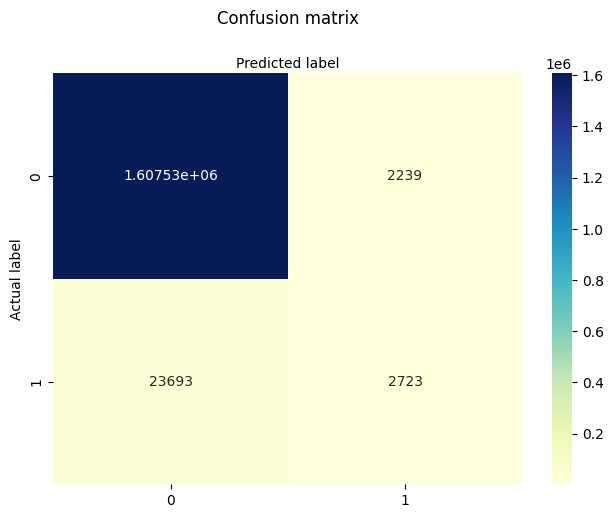

In [84]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [85]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))

              precision    recall  f1-score   support

  without IP       0.99      1.00      0.99   1609769
     with IP       0.55      0.10      0.17     26416

    accuracy                           0.98   1636185
   macro avg       0.77      0.55      0.58   1636185
weighted avg       0.98      0.98      0.98   1636185



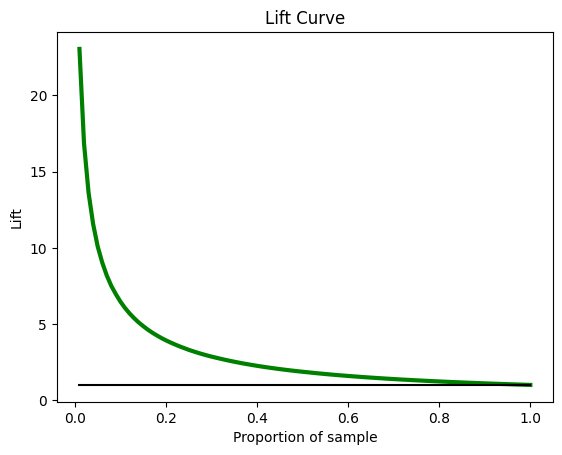

In [86]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(y_test, y_pred_test, step=0.01)


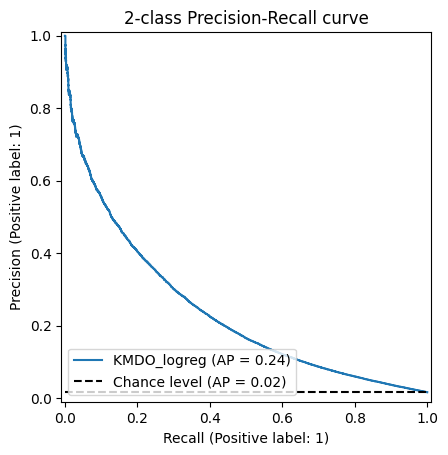

In [87]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [88]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.23700162606367814


In [89]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, y_test, model)
lift_chart.to_csv('lift_chart_xgboost.csv')
lift_chart

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.992680,0.271375,6090,16362,1.000009,23.05421,23.05421,1.000009,23.053998
1,0.271366,0.171003,2818,16362,1.000009,10.667777,33.721987,2.000018,16.860839
2,0.170998,0.125190,1886,16362,1.000009,7.139612,40.861599,3.000028,13.620408
3,0.125183,0.099363,1428,16362,1.000009,5.405815,46.267414,4.000037,11.566747
4,0.099362,0.082174,1111,16362,1.000009,4.205784,50.473198,5.000046,10.094547
...,...,...,...,...,...,...,...,...,...
95,0.002009,0.001927,22,16362,1.000009,0.083283,99.697153,95.999963,1.038512
96,0.001927,0.001838,23,16362,1.000009,0.087068,99.784222,96.999972,1.028704
97,0.001838,0.001731,16,16362,1.000009,0.060569,99.844791,97.999982,1.018825
98,0.001731,0.001599,20,16362,1.000009,0.075712,99.920503,98.999991,1.009298


In [90]:
feature_importances = model.get_booster().get_score(importance_type='weight') 
importance_df = pd.DataFrame(feature_importances.items(), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importance
print(importance_df)
importance_df.to_csv('importance_df_xgboost.csv')

                Feature  Importance
80    citizenship_index    100673.0
76               agenbr     78631.0
9     sum_op_visits_yr1     71321.0
21    coe_other_clm_yr1     66387.0
61  days_supply_sum_yr1     62517.0
..                  ...         ...
6     acute_ip_flag_yr1      3312.0
50                  MOH      3222.0
84            sum_chemo      3060.0
55                  SCA      1799.0
48                 esrd      1575.0

[91 rows x 2 columns]


In [91]:
y_pred = model.predict(X_test)
y_pred = y_test.to_frame()
y_pred = pd.DataFrame(y_pred)

threshold = 0.3

y_predict_prob =model.predict_proba(X_test)[:, 1]
y_predict_lab = ((model.predict_proba(X_test)[:, 1])>= threshold).astype(int)

y_pred['y_predict_prob'] = y_predict_prob
y_pred['y_predict_class'] = y_predict_lab
y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['acute_ip_flag'], y_pred['y_predict_class'])

y_predict_class,0,1
acute_ip_flag,,
0,1601401,8368
1,20928,5488


In [92]:
y_pred.head()

,acute_ip_flag,y_predict_prob,y_predict_class
asdb_member_key,,,
440518622,0,0.019164,0
352059428,0,0.042591,0
72736898,0,0.017380,0
281651739,0,0.016561,0
461064530,0,0.005001,0


In [93]:
df_out = pd.merge(y_pred, merged, how = 'left',left_index = True, right_index = True)

In [94]:
df_out.head()

,acute_ip_flag_x,y_predict_prob,y_predict_class,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,low_sev_ed_visits_yr1,low_med_sev_ed_visits_yr1,...,ethnicity_code_ETHN0021,ethnicity_code_ETHN0023,ethnicity_code_ETHN0025,ethnicity_code_ETHN0029,primarylanguage_desc_ARABIC,primarylanguage_desc_ENGLISH,primarylanguage_desc_No Language,primarylanguage_desc_SPANISH,primarylanguage_desc_UNKNOWN,acute_ip_flag_y
asdb_member_key,,,,,,,,,,,,,,,,,,,,,
440518622,0,0.019164,0,4,1,1,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
352059428,0,0.042591,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
72736898,0,0.017380,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
281651739,0,0.016561,0,1,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
461064530,0,0.005001,0,1,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [95]:
df_out.shape

(1636203, 388)

In [96]:
m0_3 = df_out.loc[df_out['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = df_out.loc[df_out['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = df_out.loc[df_out['tenure_yr1'].isin([9,10,11,12,13,])]

In [97]:
Foster = df_out[df_out['coa_population_category_Foster'] == 1]

ABD = df_out[(df_out['coa_population_category_DD'] == 1) | 
             (df_out['coa_population_category_ABD Non Dual Non LTSS'] == 1)]

LTSS = df_out[(df_out['coa_population_category_ABD Non Dual LTSS'] == 1) | 
              (df_out['coa_population_category_Dual Elig LTSS'] == 1) |
              (df_out['coa_population_category_Dual Int LTSS'] == 1) |
              (df_out['coa_population_category_LTSS Only'] == 1) ]

Dual = df_out[(df_out['coa_population_category_Dual Elig NonLTSS'] == 1) | 
             (df_out['coa_population_category_Dual Int NonLTSS'] == 1)]

BH = df_out[(df_out['coa_population_category_BH Int SMI'] == 1)]

Adult = df_out[(df_out['coa_population_category_Expansion'] == 1) | 
             ((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] >= 18)) |
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] >= 18))]

Kid = df_out[((df_out['coa_population_category_TANF'] == 1) & (df_out['agenbr'] < 18)) | 
             ((df_out['coa_population_category_CHIP'] == 1) & (df_out['agenbr'] < 18)) ]

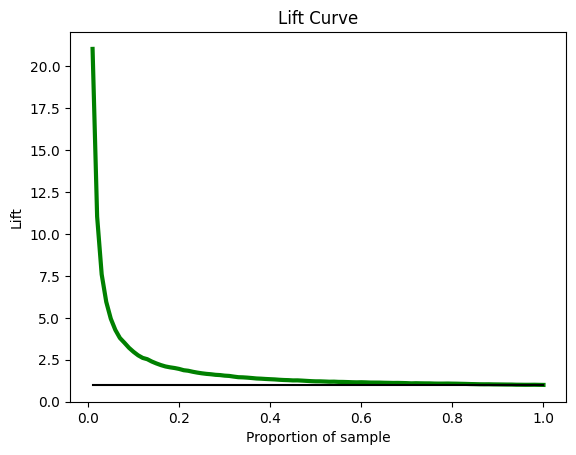

In [98]:
plot_lift_curve(Foster['acute_ip_flag_x'], Foster['y_predict_class'], step=0.01)

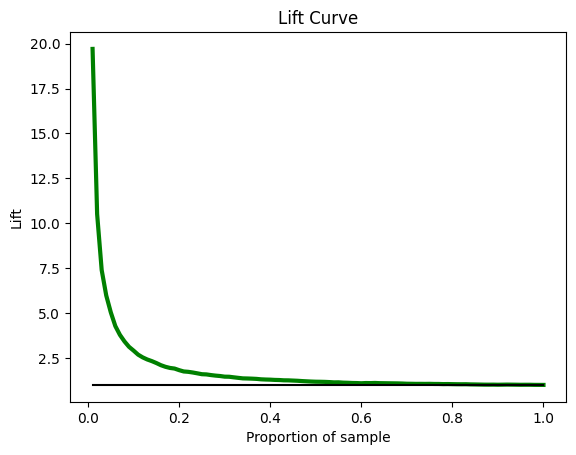

In [99]:
plot_lift_curve(LTSS['acute_ip_flag_x'], LTSS['y_predict_class'], step=0.01)

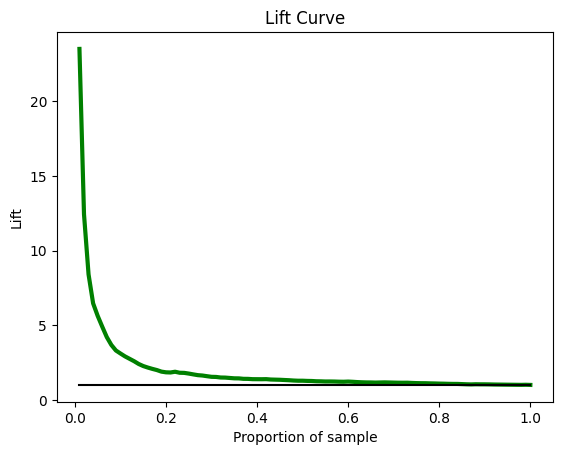

In [100]:
plot_lift_curve(Dual['acute_ip_flag_x'], Dual['y_predict_class'], step=0.01)

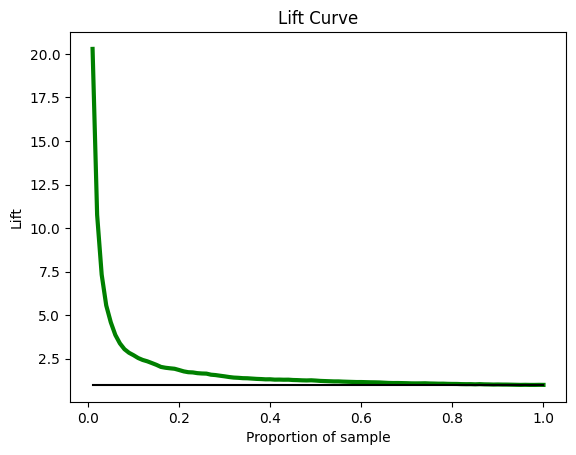

In [101]:
plot_lift_curve(BH['acute_ip_flag_x'], BH['y_predict_class'], step=0.01)

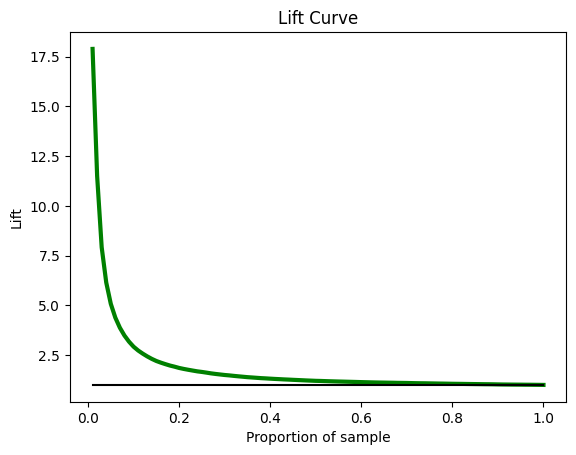

In [102]:
plot_lift_curve(Adult['acute_ip_flag_x'], Adult['y_predict_class'], step=0.01)

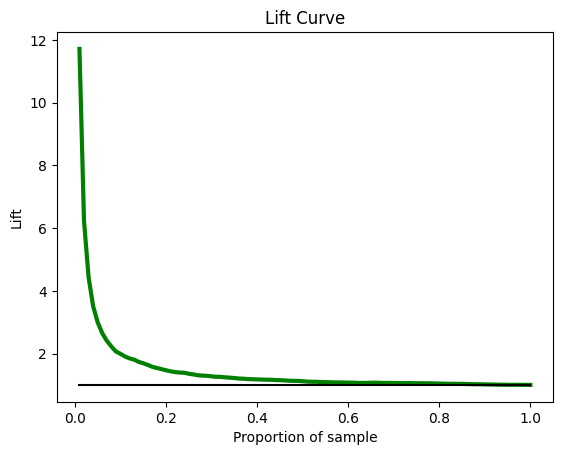

In [103]:
plot_lift_curve(Kid['acute_ip_flag_x'], Kid['y_predict_class'], step=0.01)

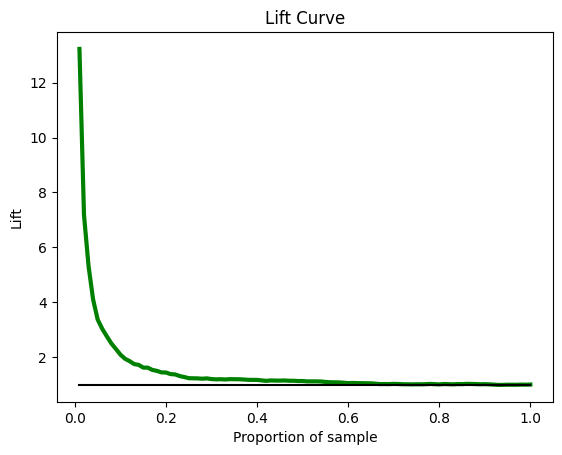

In [104]:
plot_lift_curve(m0_3['acute_ip_flag_x'], m0_3['y_predict_class'], step=0.01)

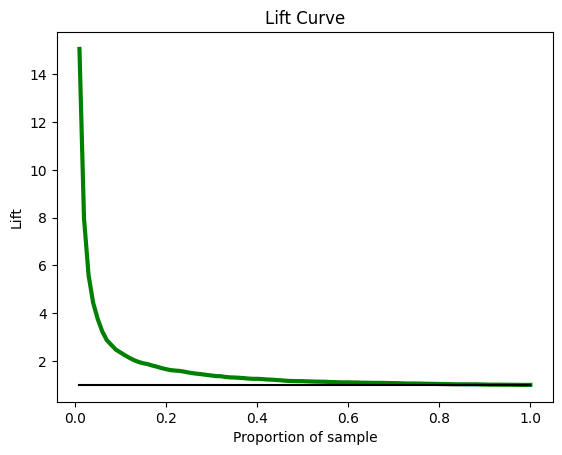

In [105]:
plot_lift_curve(m4_8['acute_ip_flag_x'], m4_8['y_predict_class'], step=0.01)

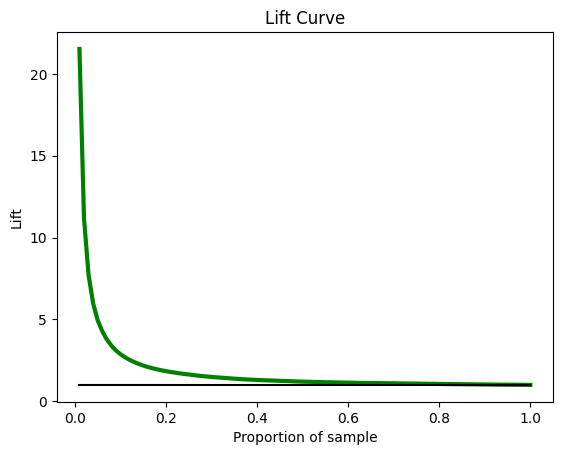

In [106]:
plot_lift_curve(m_9_13['acute_ip_flag_x'], m_9_13['y_predict_class'], step=0.01)

In [107]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [108]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.826960,0.047528,231,2556,10.003522,51.910112,51.910112,10.003522,5.189183
1,0.047525,0.028391,72,2555,9.999609,16.179775,68.089888,20.003131,3.403961
2,0.028391,0.020080,50,2555,9.999609,11.235955,79.325843,30.00274,2.643953
3,0.020079,0.013737,31,2555,9.999609,6.966292,86.292135,40.002348,2.157177
4,0.013736,0.009056,15,2555,9.999609,3.370787,89.662921,50.001957,1.793188
5,0.009055,0.006731,15,2555,9.999609,3.370787,93.033708,60.001565,1.550521
6,0.006730,0.005356,13,2555,9.999609,2.921348,95.955056,70.001174,1.370764
7,0.005356,0.004274,6,2555,9.999609,1.348315,97.303371,80.000783,1.21628
8,0.004273,0.003559,6,2555,9.999609,1.348315,98.651685,90.000391,1.096125
9,0.003559,0.001805,6,2555,9.999609,1.348315,100.0,100.0,1.0


In [109]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.907533,0.049925,1080,11345,10.000529,56.338028,56.338028,10.000529,5.633505
1,0.049924,0.027751,259,11344,9.999647,13.510694,69.848722,20.000176,3.492405
2,0.027750,0.019248,183,11344,9.999647,9.546166,79.394888,29.999824,2.646512
3,0.019248,0.014031,145,11345,10.000529,7.563902,86.95879,40.000353,2.173951
4,0.014031,0.009984,90,11344,9.999647,4.694836,91.653625,50.0,1.833073
5,0.009983,0.007256,45,11344,9.999647,2.347418,94.001043,59.999647,1.566693
6,0.007256,0.005391,43,11345,10.000529,2.243088,96.244131,70.000176,1.374913
7,0.005391,0.004065,26,11344,9.999647,1.356286,97.600417,79.999824,1.220008
8,0.004065,0.003077,25,11344,9.999647,1.304121,98.904538,89.999471,1.098946
9,0.003077,0.001265,21,11345,10.000529,1.095462,100.0,100.0,1.0


In [110]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.992680,0.043533,15762,149718,10.0,65.549364,65.549364,10.0,6.554936
1,0.043533,0.021273,3295,149718,10.0,13.702903,79.252266,20.0,3.962613
2,0.021273,0.013014,1675,149718,10.0,6.965816,86.218082,30.0,2.873936
3,0.013013,0.008773,994,149718,10.0,4.133744,90.351826,40.0,2.258796
4,0.008773,0.006383,735,149718,10.0,3.056641,93.408467,50.0,1.868169
5,0.006383,0.004904,479,149718,10.0,1.992015,95.400482,60.0,1.590008
6,0.004904,0.003833,385,149718,10.0,1.601098,97.00158,70.0,1.385737
7,0.003833,0.002997,303,149718,10.0,1.260085,98.261665,80.0,1.228271
8,0.002997,0.002333,223,149718,10.0,0.927389,99.189054,90.0,1.102101
9,0.002333,0.000472,195,149718,10.0,0.810946,100.0,100.0,1.0


In [111]:
lift_chart(Foster)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.988093,0.045796,528,5378,10.001116,61.040462,61.040462,10.001116,6.103365
1,0.045796,0.022656,118,5377,9.999256,13.641618,74.682081,20.000372,3.734035
2,0.022652,0.013902,71,5377,9.999256,8.208092,82.890173,29.999628,2.76304
3,0.013900,0.009305,52,5378,10.001116,6.011561,88.901734,40.000744,2.222502
4,0.009305,0.006635,25,5377,9.999256,2.890173,91.791908,50.0,1.835838
5,0.006634,0.005092,23,5377,9.999256,2.65896,94.450867,59.999256,1.574201
6,0.005092,0.003956,17,5378,10.001116,1.965318,96.416185,70.000372,1.377367
7,0.003956,0.003095,15,5377,9.999256,1.734104,98.150289,79.999628,1.226884
8,0.003095,0.002382,11,5377,9.999256,1.271676,99.421965,89.998884,1.104702
9,0.002382,0.000631,5,5378,10.001116,0.578035,100.0,100.0,1.0


In [112]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.986004,0.044040,1258,12009,10.00025,65.384615,65.384615,10.00025,6.538298
1,0.044032,0.021817,259,12009,10.00025,13.461538,78.846154,20.0005,3.942209
2,0.021817,0.013582,144,12008,9.999417,7.484407,86.330561,29.999917,2.877693
3,0.013582,0.009164,76,12009,10.00025,3.950104,90.280665,40.000167,2.257007
4,0.009164,0.006598,59,12009,10.00025,3.066528,93.347193,50.000416,1.866928
5,0.006598,0.005037,35,12008,9.999417,1.819127,95.16632,59.999833,1.58611
6,0.005037,0.003931,37,12009,10.00025,1.923077,97.089397,70.000083,1.38699
7,0.003931,0.003068,20,12008,9.999417,1.039501,98.128898,79.9995,1.226619
8,0.003068,0.002382,18,12009,10.00025,0.935551,99.064449,89.99975,1.100719
9,0.002382,0.000537,18,12009,10.00025,0.935551,100.0,100.0,1.0


In [113]:
lift_chart(LTSS)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.975642,0.044778,429,4153,10.001686,61.815562,61.815562,10.001686,6.180514
1,0.044774,0.022216,105,4152,9.999278,15.129683,76.945245,20.000963,3.847077
2,0.022215,0.013711,43,4152,9.999278,6.195965,83.14121,30.000241,2.771351
3,0.013710,0.009160,36,4152,9.999278,5.18732,88.32853,39.999518,2.20824
4,0.009159,0.006596,24,4153,10.001686,3.458213,91.786744,50.001204,1.835691
5,0.006596,0.005050,16,4152,9.999278,2.305476,94.092219,60.000482,1.568191
6,0.005050,0.003927,17,4152,9.999278,2.449568,96.541787,69.999759,1.379173
7,0.003927,0.003080,10,4152,9.999278,1.440922,97.982709,79.999037,1.224799
8,0.003080,0.002389,9,4152,9.999278,1.29683,99.279539,89.998314,1.103127
9,0.002389,0.000626,5,4153,10.001686,0.720461,100.0,100.0,1.0


In [114]:
lift_chart(Dual)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.916920,0.043040,208,1921,10.004166,67.313916,67.313916,10.004166,6.728588
1,0.043037,0.022157,40,1920,9.998958,12.944984,80.2589,20.003125,4.012318
2,0.022157,0.013865,24,1920,9.998958,7.76699,88.02589,30.002083,2.933993
3,0.013864,0.009206,8,1920,9.998958,2.588997,90.614887,40.001042,2.265313
4,0.009204,0.006674,12,1920,9.998958,3.883495,94.498382,50.0,1.889968
5,0.006673,0.005090,5,1920,9.998958,1.618123,96.116505,59.998958,1.60197
6,0.005089,0.003973,4,1920,9.998958,1.294498,97.411003,69.997917,1.391627
7,0.003973,0.003086,3,1920,9.998958,0.970874,98.381877,79.996875,1.229821
8,0.003085,0.002390,3,1920,9.998958,0.970874,99.352751,89.995834,1.103971
9,0.002389,0.001076,2,1921,10.004166,0.647249,100.0,100.0,1.0


In [115]:
lift_chart(BH)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.969879,0.043553,267,2664,10.000375,63.875598,63.875598,10.000375,6.38732
1,0.043552,0.021798,44,2664,10.000375,10.526316,74.401914,20.000751,3.719956
2,0.021787,0.013736,42,2664,10.000375,10.047847,84.449761,30.001126,2.814886
3,0.013734,0.009185,19,2664,10.000375,4.545455,88.995215,40.001502,2.224797
4,0.009185,0.006679,16,2664,10.000375,3.827751,92.822967,50.001877,1.85639
5,0.006679,0.005095,10,2663,9.996621,2.392344,95.215311,59.998498,1.586962
6,0.005095,0.003971,11,2664,10.000375,2.631579,97.84689,69.998874,1.397835
7,0.003970,0.003103,2,2664,10.000375,0.478469,98.325359,79.999249,1.229079
8,0.003103,0.002388,4,2664,10.000375,0.956938,99.282297,89.999625,1.103141
9,0.002388,0.000870,3,2664,10.000375,0.717703,100.0,100.0,1.0


In [116]:
lift_chart(Adult)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.992680,0.062734,11697,86784,10.000058,61.132016,61.132016,10.000058,6.113166
1,0.062734,0.031917,2857,86783,9.999942,14.931535,76.063552,20.0,3.803178
2,0.031917,0.020440,1583,86784,10.000058,8.273231,84.336783,30.000058,2.811221
3,0.020439,0.014060,948,86783,9.999942,4.954531,89.291314,40.0,2.232283
4,0.014060,0.010020,660,86784,10.000058,3.449357,92.740671,50.000058,1.854811
5,0.010020,0.007381,456,86783,9.999942,2.383192,95.123863,60.0,1.585398
6,0.007381,0.005604,354,86783,9.999942,1.85011,96.973973,69.999942,1.385344
7,0.005604,0.004247,241,86784,10.000058,1.259538,98.233511,80.0,1.227919
8,0.004247,0.003007,212,86783,9.999942,1.107975,99.341486,89.999942,1.103795
9,0.003007,0.000472,126,86784,10.000058,0.658514,100.0,100.0,1.0


In [117]:
lift_chart(Kid)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.966683,0.014789,1828,50439,10.000079,59.973753,59.973753,10.000079,5.997328
1,0.014788,0.008255,358,50439,10.000079,11.745407,71.71916,20.000159,3.58593
2,0.008255,0.005877,213,50438,9.999881,6.988189,78.707349,30.00004,2.623575
3,0.005877,0.004631,158,50439,10.000079,5.183727,83.891076,40.000119,2.097271
4,0.004631,0.003837,109,50438,9.999881,3.576115,87.467192,50.0,1.749344
5,0.003837,0.003254,95,50439,10.000079,3.116798,90.58399,60.000079,1.509731
6,0.003254,0.002803,86,50438,9.999881,2.821522,93.405512,69.99996,1.334365
7,0.002803,0.002423,76,50439,10.000079,2.493438,95.89895,80.00004,1.198736
8,0.002423,0.002028,58,50438,9.999881,1.902887,97.801837,89.999921,1.086688
9,0.002028,0.000858,67,50439,10.000079,2.198163,100.0,100.0,1.0


In [118]:
def lift_chart(df):
    avg_tgt = df['acute_ip_flag_x']/len(df['acute_ip_flag_x'])
    df_data = df.copy()
    df_data['Actual'] = df['acute_ip_flag_x']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_predict_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['acute_ip_flag_x']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df  

In [119]:
lift_chart(df_out[df_out['tenure_yr1'].isin([0,1,2,3])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.826960,0.230553,82,256,1.001918,18.426966,18.426966,1.001918,18.391696
1,0.229977,0.156019,25,256,1.001918,5.617978,24.044944,2.003835,11.99946
2,0.155599,0.120640,28,255,0.998004,6.292135,30.337079,3.001839,10.106163
3,0.120631,0.098830,20,256,1.001918,4.494382,34.831461,4.003757,8.699694
4,0.098634,0.082979,16,255,0.998004,3.595506,38.426966,5.001761,7.682687
...,...,...,...,...,...,...,...,...,...
95,0.003191,0.003097,0,256,1.001918,0.0,99.550562,96.000157,1.036983
96,0.003096,0.002998,1,255,0.998004,0.224719,99.775281,96.998161,1.028631
97,0.002997,0.002855,0,256,1.001918,0.0,99.775281,98.000078,1.018114
98,0.002855,0.002692,1,255,0.998004,0.224719,100.0,98.998082,1.010121


In [120]:
lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.907533,0.251477,361,1135,1.000494,18.831508,18.831508,1.000494,18.822216
1,0.251475,0.168019,154,1134,0.999612,8.033385,26.864893,2.000106,13.431736
2,0.168012,0.127700,106,1135,1.000494,5.529473,32.394366,3.000599,10.795965
3,0.127673,0.104491,93,1134,0.999612,4.85133,37.245696,4.000212,9.310932
4,0.104486,0.087961,89,1135,1.000494,4.642671,41.888367,5.000705,8.376492
...,...,...,...,...,...,...,...,...,...
95,0.002658,0.002563,2,1135,1.000494,0.10433,99.634846,95.999788,1.037865
96,0.002563,0.002463,6,1134,0.999612,0.312989,99.947835,96.999401,1.030396
97,0.002463,0.002337,0,1135,1.000494,0.0,99.947835,97.999894,1.019877
98,0.002337,0.002170,1,1134,0.999612,0.052165,100.0,98.999506,1.010106


In [121]:
lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.992680,0.274099,5634,14972,1.000013,23.430092,23.430092,1.000013,23.429779
1,0.274092,0.171515,2644,14972,1.000013,10.995592,34.425684,2.000027,17.212612
2,0.171512,0.125083,1753,14972,1.000013,7.290194,41.715878,3.00004,13.905107
3,0.125081,0.098940,1311,14972,1.000013,5.45205,47.167928,4.000053,11.791825
4,0.098939,0.081633,1021,14971,0.999947,4.246028,51.413957,5.0,10.282791
...,...,...,...,...,...,...,...,...,...
95,0.001977,0.001900,12,14971,0.999947,0.049904,99.683939,95.999947,1.038375
96,0.001900,0.001814,21,14972,1.000013,0.087333,99.771272,96.99996,1.02857
97,0.001814,0.001712,17,14972,1.000013,0.070698,99.84197,97.999973,1.018796
98,0.001712,0.001585,18,14972,1.000013,0.074857,99.916826,98.999987,1.009261


In [122]:
lift_chart(Foster) 

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.988093,0.281751,194,538,1.000484,22.427746,22.427746,1.000484,22.416907
1,0.281562,0.172865,84,538,1.000484,9.710983,32.138728,2.000967,16.061598
2,0.172857,0.129082,67,538,1.000484,7.745665,39.884393,3.001451,13.288373
3,0.129007,0.104263,43,537,0.998624,4.971098,44.855491,4.000074,11.213664
4,0.104239,0.086097,28,538,1.000484,3.236994,48.092486,5.000558,9.617424
...,...,...,...,...,...,...,...,...,...
95,0.002013,0.001931,1,538,1.000484,0.115607,100.0,95.999926,1.041667
96,0.001931,0.001836,0,537,0.998624,0.0,100.0,96.998549,1.030943
97,0.001836,0.001731,0,538,1.000484,0.0,100.0,97.999033,1.020418
98,0.001730,0.001604,0,538,1.000484,0.0,100.0,98.999516,1.010106


In [123]:
lift_chart(ABD)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.986004,0.271209,438,1201,1.000108,22.765073,22.765073,1.000108,22.762609
1,0.271110,0.169633,217,1201,1.000108,11.278586,34.043659,2.000217,17.019987
2,0.169614,0.124602,160,1201,1.000108,8.316008,42.359667,3.000325,14.118361
3,0.124566,0.099648,100,1201,1.000108,5.197505,47.557173,4.000433,11.888006
4,0.099641,0.081907,85,1201,1.000108,4.417879,51.975052,5.000541,10.393885
...,...,...,...,...,...,...,...,...,...
95,0.002004,0.001923,0,1201,1.000108,0.0,99.532225,95.999567,1.036799
96,0.001923,0.001836,3,1201,1.000108,0.155925,99.68815,96.999675,1.027716
97,0.001836,0.001730,5,1201,1.000108,0.259875,99.948025,97.999783,1.01988
98,0.001730,0.001598,0,1201,1.000108,0.0,99.948025,98.999892,1.009577


In [124]:
lift_chart(LTSS)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.975642,0.267995,148,416,1.001854,21.325648,21.325648,1.001854,21.286175
1,0.267338,0.170207,66,415,0.999446,9.510086,30.835735,2.0013,15.407849
2,0.170065,0.127152,45,415,0.999446,6.48415,37.319885,3.000747,12.436867
3,0.127108,0.100883,40,415,0.999446,5.763689,43.083573,4.000193,10.770375
4,0.100841,0.082916,31,416,1.001854,4.466859,47.550432,5.002047,9.506195
...,...,...,...,...,...,...,...,...,...
95,0.002014,0.001935,0,416,1.001854,0.0,99.567723,95.999807,1.037166
96,0.001934,0.001845,0,415,0.999446,0.0,99.567723,96.999253,1.026479
97,0.001845,0.001745,0,415,0.999446,0.0,99.567723,97.9987,1.016011
98,0.001745,0.001606,2,415,0.999446,0.288184,99.855908,98.998146,1.008664


In [125]:
lift_chart(Dual)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.916920,0.274099,77,193,1.005104,24.919094,24.919094,1.005104,24.792562
1,0.273967,0.179428,36,192,0.999896,11.650485,36.569579,2.004999,18.239196
2,0.179334,0.121920,30,192,0.999896,9.708738,46.278317,3.004895,15.400975
3,0.121894,0.095859,25,192,0.999896,8.090615,54.368932,4.004791,13.575972
4,0.095848,0.078009,11,192,0.999896,3.559871,57.928803,5.004687,11.57491
...,...,...,...,...,...,...,...,...,...
95,0.002008,0.001927,0,192,0.999896,0.0,100.0,95.995209,1.041719
96,0.001926,0.001836,0,192,0.999896,0.0,100.0,96.995105,1.03098
97,0.001836,0.001722,0,192,0.999896,0.0,100.0,97.995001,1.02046
98,0.001720,0.001588,0,192,0.999896,0.0,100.0,98.994896,1.010153


In [126]:
lift_chart(BH)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.969879,0.259577,94,267,1.00229,22.488038,22.488038,1.00229,22.436661
1,0.259471,0.166561,45,266,0.998536,10.76555,33.253589,2.000826,16.619931
2,0.166095,0.122760,28,267,1.00229,6.698565,39.952153,3.003116,13.303568
3,0.122633,0.096069,18,266,0.998536,4.30622,44.258373,4.001652,11.060026
4,0.095900,0.079185,14,266,0.998536,3.349282,47.607656,5.000188,9.521174
...,...,...,...,...,...,...,...,...,...
95,0.001998,0.001911,0,266,0.998536,0.0,99.521531,95.998348,1.0367
96,0.001910,0.001835,2,266,0.998536,0.478469,100.0,96.996884,1.030961
97,0.001834,0.001730,0,267,1.00229,0.0,100.0,97.999174,1.020417
98,0.001730,0.001598,0,266,0.998536,0.0,100.0,98.99771,1.010124


In [127]:
lift_chart(Adult)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.992680,0.339952,3714,8679,1.000075,19.410474,19.410474,1.000075,19.40902
1,0.339907,0.224192,1972,8678,0.99996,10.306261,29.716735,2.000035,14.85811
2,0.224176,0.169732,1340,8679,1.000075,7.00324,36.719975,3.000109,12.239545
3,0.169726,0.136158,1025,8678,0.99996,5.356956,42.076931,4.000069,10.519051
4,0.136158,0.113887,843,8678,0.99996,4.40577,46.482701,5.000029,9.296487
...,...,...,...,...,...,...,...,...,...
95,0.002404,0.002266,9,8678,0.99996,0.047037,99.754364,95.999931,1.039109
96,0.002266,0.002115,16,8678,0.99996,0.083621,99.837985,96.999891,1.029259
97,0.002115,0.001949,12,8679,1.000075,0.062716,99.9007,97.999965,1.019395
98,0.001949,0.001745,9,8678,0.99996,0.047037,99.947737,98.999925,1.009574


In [128]:
lift_chart(Kid)

,Max_Scr,Min_Scr,Actual,Total,Population_perc,Per_Events,Gain_Percentage,Cumulative_Population,Lift
0,0.966683,0.077499,812,5044,1.000028,26.64042,26.64042,1.000028,26.639681
1,0.077498,0.047088,258,5044,1.000028,8.464567,35.104987,2.000056,17.552006
2,0.047087,0.035550,172,5044,1.000028,5.643045,40.748031,3.000083,13.5823
3,0.035549,0.029103,144,5044,1.000028,4.724409,45.472441,4.000111,11.367795
4,0.029101,0.024874,111,5044,1.000028,3.641732,49.114173,5.000139,9.822562
...,...,...,...,...,...,...,...,...,...
95,0.001800,0.001743,6,5044,1.000028,0.19685,99.081365,95.999889,1.032099
96,0.001743,0.001682,5,5044,1.000028,0.164042,99.245407,96.999917,1.023149
97,0.001682,0.001610,9,5044,1.000028,0.295276,99.540682,97.999944,1.015722
98,0.001610,0.001508,9,5044,1.000028,0.295276,99.835958,98.999972,1.008444
